# Computational Social Science Project #3 

**Enter your Name:** Hesham Jarmakani

*Semester:* Fall 2025

## 1. Introduction

### Load data 

In [9]:
#
# load libraries
# -----------
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelBinarizer

# There are a few warnings that will appear that will not affect your analysis. Run this code to ignore. 
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Make sure to import other libraries that will be necessary for training models!

In [60]:
#
# read in "Inspections Data 2011-2013" csv data
# -----------
chicago_inspections_2011_to_2013 = pd.read_csv("Chicago Inspections 2011-2013.csv", 
                                              low_memory=False)

#
# read in  "Inspections Data 2014_updated" csv data
# -----------
chicago_inspections_2014 = pd.read_csv("Chicago Inspections 2014_updated.csv",  # be sure to use the "updated" data here
                                      low_memory=False)

In [62]:
# look at the inspections data
chicago_inspections_2011_to_2013.head()

,Inspection_ID,Inspection_Date,DBA_Name,AKA_Name,License,Facility_Type,Risk,Address,City,State,Zip,Inspection_Type,Latitude,Longitude,Location,Facility_Type_Clean,criticalCount,seriousCount,minorCount,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,ID,LICENSE_ID,ACCOUNT_NUMBER,LEGAL_NAME,DOING_BUSINESS_AS_NAME,ADDRESS,CITY,STATE,ZIP_CODE,WARD,PRECINCT,WARD_PRECINCT,POLICE_DISTRICT,LICENSE_CODE,LICENSE_DESCRIPTION,BUSINESS_ACTIVITY_ID,BUSINESS_ACTIVITY,LICENSE_NUMBER,APPLICATION_TYPE,LICENSE_TERM_START_DATE,LICENSE_TERM_EXPIRATION_DATE,LICENSE_STATUS,LATITUDE,LONGITUDE,minDate,maxDate,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound,Results
0,920444,2014-01-15,GALLISTEL LANGUAGE ACADEMY,GALLISTEL LANGUAGE ACADEMY,2046708,School,Risk 1 (High),10200 S AVENUE J,CHICAGO,IL,60617.0,Canvass,41.709957,-87.534223,"(41.70995714781606, -87.5342225149751)",Other,0,1,5,0,0,0,2,0.964384,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,41.67,13.533333,0.726667,2.149376,7.705332,9.535848,0,Fail
1,920445,2014-02-03,SUBWAY,SUBWAY,2183563,Restaurant,Risk 1 (High),4025 E 106TH ST,CHICAGO,IL,60617.0,Canvass,41.702577,-87.525872,"(41.70257660937248, -87.52587169711877)",Restaurant,2,0,0,0,0,0,0,0.794521,0,2183563-20120829,2183563.0,375027.0,AMI SUB INC.,SUBWAY,4025 E 106TH ST 1,CHICAGO,IL,60617.0,10.0,38.0,10-38,4.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,2183563.0,ISSUE,2012-08-29,2014-09-15,AAI,41.702577,-87.525872,2012-08-29,2018-09-15,1.432877,0,0,0,0,0,0,0,0,0,0,0,0,0.002300,28.16,6.020000,0.746667,12.034833,7.194320,1.219222,1,Pass w/ Conditions
2,920446,2014-02-03,SHARKS FISH & CHICKEN,SHARKS FISH & CHICKEN,1477112,Restaurant,Risk 2 (Medium),2027 E 95TH ST,CHICAGO,IL,60617.0,Canvass,41.722372,-87.574275,"(41.72237211196818, -87.57427469548966)",Restaurant,0,0,6,0,0,0,2,0.660274,0,1477112-20120716,2155150.0,273266.0,"A & K SHARKS, INC.",SHARKS FISH & CHICKEN,2027 E 95TH ST,CHICAGO,IL,60617.0,7.0,49.0,7-49,4.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1477112.0,RENEW,2012-07-16,2014-07-15,AAI,41.722372,-87.574275,2004-03-02,2018-07-15,9.931507,0,0,0,0,0,0,0,0,0,0,0,0,0.002300,28.16,6.020000,0.746667,26.292725,27.837325,12.401466,0,Pass
3,920448,2014-03-07,P K PETRO INC.,MARATHON,1331469,Grocery Store,Risk 3 (Low),7001 S STONY ISLAND AVE,CHICAGO,IL,60649.0,Canvass,41.767798,-87.585820,"(41.76779762303839, -87.58581991823232)",Other,0,1,7,0,0,0,0,2.000000,1,1331469-20121216,2194284.0,257899.0,P K PETRO INC.,Stony Shell,7001 S STONY ISLAND AVE,CHICAGO,IL,60649.0,5.0,21.0,5-21,3.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1331469.0,RENEW,2012-12-16,2014-12-15,AAI,41.767798,-87.585820,2003-03-05,2018-12-15,11.013699,0,1,0,0,0,0,0,0,0,1,0,0,0.000433,25.30,7.653333,0.636667,49.468944,11.282325,66.467028,0,Fail
4,920449,2014-03-07,"Z T DOLLAR EXCHANGE,INC",DOLLAR STORE,2189299,Grocery Store,Risk 3 (Low),2429 E 72ND ST,CHICAGO,IL,60649.0,Canvass,41.764339,-87.565371,"(41.764339216775696, -87.5653706801239)",Other,1,2,5,0,0,0,0,2.000000,1,2189299-20121009,2189299.0,249904.0,"ZT DOLLAR EXCHANGE, INC.","Z T DOLLAR EXCHANGE, INC.",2429 E 72ND ST,CHICAGO,IL,60649.0,7.0,40.0,7-40,3.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,2189299.0,ISSUE,2012-10-09,2014-12-15,AAI,41.764339,-87.565371,2012-10-09,2018-12-15,1.408219,0,1,0,0,0,1,0,0,0,0,0,0,0.000433,25.30,7.653333,0.636667,69.939833,26.695701,76.827119,1,Fail


In [12]:
# list column names
chicago_inspections_2011_to_2013.columns

Index(['Inspection_ID', 'Inspection_Date', 'DBA_Name', 'AKA_Name', 'License',
       'Facility_Type', 'Risk', 'Address', 'City', 'State', 'Zip',
       'Inspection_Type', 'Results', 'Latitude', 'Longitude', 'Location',
       'Facility_Type_Clean', 'criticalCount', 'seriousCount', 'minorCount',
       'pass_flag', 'fail_flag', 'pastFail', 'pastCritical', 'pastSerious',
       'pastMinor', 'timeSinceLast', 'firstRecord', 'ID', 'LICENSE_ID',
       'ACCOUNT_NUMBER', 'LEGAL_NAME', 'DOING_BUSINESS_AS_NAME', 'ADDRESS',
       'CITY', 'STATE', 'ZIP_CODE', 'WARD', 'PRECINCT', 'WARD_PRECINCT',
       'POLICE_DISTRICT', 'LICENSE_CODE', 'LICENSE_DESCRIPTION',
       'BUSINESS_ACTIVITY_ID', 'BUSINESS_ACTIVITY', 'LICENSE_NUMBER',
       'APPLICATION_TYPE', 'LICENSE_TERM_START_DATE',
       'LICENSE_TERM_EXPIRATION_DATE', 'LICENSE_STATUS', 'LATITUDE',
       'LONGITUDE', 'minDate', 'maxDate', 'ageAtInspection',
       'consumption_on_premises_incidental_activity', 'tobacco',
       'package_goods',

In [13]:
# drop column names related to geography, identification, and pass/fail flags that perfectly predict the outcome
chicago_inspections_2011_to_2013.drop(columns = ['AKA_Name', 
                                                 'License',
                                                 'Address',
                                                 'City',
                                                 'State',
                                                 'Zip',
                                                 'Latitude',
                                                 'Longitude',
                                                 'Location',
                                                 'ID',
                                                 'LICENSE_ID',
                                                 'LICENSE_TERM_START_DATE',
                                                 'LICENSE_TERM_EXPIRATION_DATE',
                                                 'LICENSE_STATUS',
                                                 'ACCOUNT_NUMBER',
                                                 'LEGAL_NAME',
                                                 'DOING_BUSINESS_AS_NAME',
                                                 'ADDRESS',
                                                 'CITY',
                                                 'STATE',
                                                 'ZIP_CODE',
                                                 'WARD',
                                                 'PRECINCT',
                                                 'LICENSE_CODE',
                                                 'BUSINESS_ACTIVITY_ID',
                                                 'BUSINESS_ACTIVITY',
                                                 'LICENSE_NUMBER',
                                                 'LATITUDE',
                                                 'LONGITUDE',
                                                 'pass_flag',
                                                 'fail_flag'],
                                     inplace = True)

# set index
chicago_inspections_2011_to_2013.set_index(['Inspection_ID', 'DBA_Name'], inplace = True)

In [14]:
# convert the inspection date to a datetime format
chicago_inspections_2011_to_2013['Inspection_Date'] = pd.to_datetime(chicago_inspections_2011_to_2013['Inspection_Date'])  

### Visualization

Let's visualize what inspections look like over time.

In [15]:
# visualize inspections over time
# -----------
chicago_inspections_2011_to_2013['Inspection_MonthYear'] = chicago_inspections_2011_to_2013['Inspection_Date'].dt.to_period('M')
counts_by_day = chicago_inspections_2011_to_2013.groupby('Inspection_MonthYear').count().rename(columns = {'Facility_Type': 'Count'})['Count'].reset_index()
counts_by_day.set_index(["Inspection_MonthYear"], inplace = True)
counts_by_day.plot(title = "Inspections by Month and Year") 

<Axes: title={'center': 'Inspections by Month and Year'}, xlabel='Inspection_MonthYear'>

Let's visualize what the distribution of results looks like.

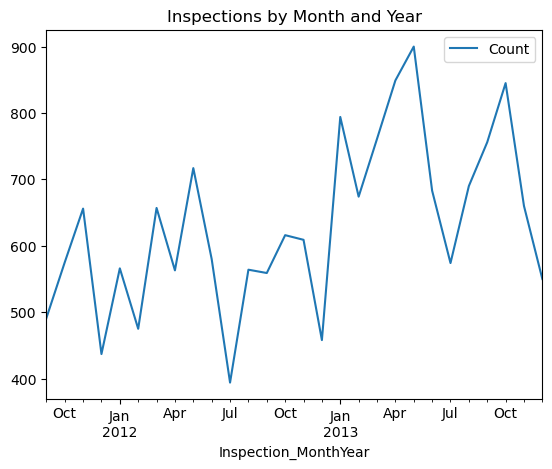

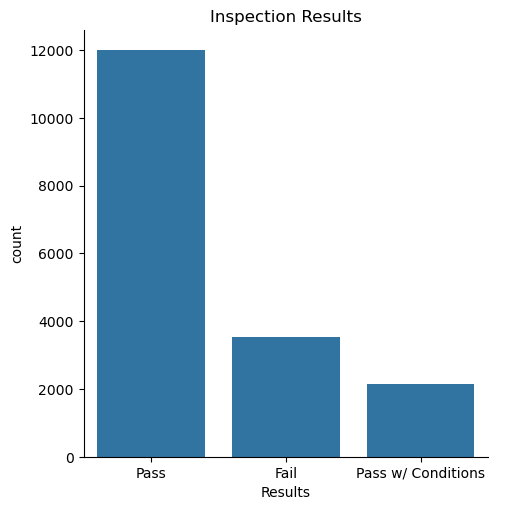

In [16]:
# view inspection results
# -----------
sns.catplot(data = chicago_inspections_2011_to_2013,
           x = "Results",
           kind = "count")

plt.title("Inspection Results")
plt.show()

What if we separate results by facility type?

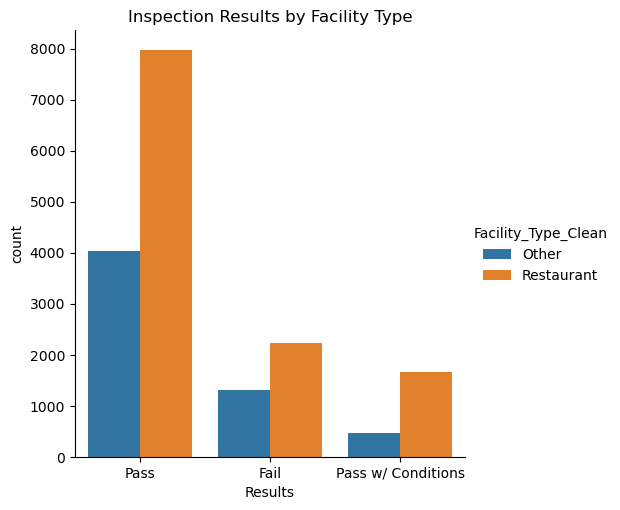

In [17]:
# view inspection results by facility type (restaurant or not)
# -----------
sns.catplot(data = chicago_inspections_2011_to_2013,
            x = "Results",
            kind = "count",
            hue = 'Facility_Type_Clean')

plt.title("Inspection Results by Facility Type")
plt.show();

## 2. Data Preprocessing and Cleaning

In [18]:
# drop datetime info
# -----------
chicago_inspections_2011_to_2013 = chicago_inspections_2011_to_2013.dropna().drop(['Inspection_Date',
                                                                                   'minDate',
                                                                                   'maxDate',
                                                                                   'Inspection_MonthYear'],
                                                                                  axis = 1)

In [19]:
# process target 
# -----------
y = chicago_inspections_2011_to_2013['Results']

# decide if you want to binarize the outcome variable 
# -----------
# comment out the following lines of code if you don't want to binarize the target variable
y = y.replace({'Pass w/ Conditions': 'Pass'})
lb_style = LabelBinarizer()
y = lb_style.fit_transform(y)

# recode 0s and 1s so 1s are "Fail"
y = np.where(y == 1, 0 ,1)


# process features
# -----------

# create feature dataset
X = chicago_inspections_2011_to_2013.drop(columns = ['Results', 
                                                     'Facility_Type', 
                                                     'LICENSE_DESCRIPTION', 
                                                     'WARD_PRECINCT'])


# get dummies
X = pd.get_dummies(X)

In [20]:
# view feature datset
X.head()

,,criticalCount,seriousCount,minorCount,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,POLICE_DISTRICT,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound,Risk_Risk 1 (High),Risk_Risk 2 (Medium),Risk_Risk 3 (Low),Inspection_Type_Canvass,Facility_Type_Clean_Other,Facility_Type_Clean_Restaurant,APPLICATION_TYPE_C_EXPA,APPLICATION_TYPE_C_LOC,APPLICATION_TYPE_ISSUE,APPLICATION_TYPE_RENEW
Inspection_ID,DBA_Name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
269961,SEVEN STAR,0,0,2,0,0,0,0,2.0,1,19.0,10.964384,0,1,0,0,0,1,0,0,0,0,0,0,0.014587,53.496667,13.340000,0.900000,26.992376,12.768572,37.748787,0,False,False,True,True,True,False,False,False,False,True
507211,PANERA BREAD,0,0,3,0,0,0,0,2.0,1,24.0,7.457534,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,13.976557,12.895485,15.412267,0,True,False,False,True,False,True,False,False,False,True
507212,LITTLE QUIAPO RESTAURANT,0,2,6,0,0,0,0,2.0,1,17.0,4.578082,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,12.611239,8.004220,8.320330,0,True,False,False,True,False,True,False,False,False,True
507216,SERGIO'S TAQUERIA PIZZA INC.,0,0,6,0,0,0,0,2.0,1,17.0,7.805479,0,0,0,0,0,0,0,0,0,0,0,0,0.002737,56.153333,10.863333,0.616667,35.906383,26.238645,38.186618,0,True,False,False,True,False,True,False,False,False,True
507219,TARGET STORE # T-2079,0,2,6,0,0,0,0,2.0,1,24.0,5.290411,0,0,1,0,0,1,0,0,0,0,0,0,0.009987,52.730000,16.266667,0.690000,9.530785,3.401567,2.126788,0,False,True,False,True,False,True,False,False,False,True


## 3. Fit Models

Now choose 3 different machine learning techniques and apply them below. Choose from one of the algorithms we have used in lab (e.g., logistic regression, random forests, `AdaBoost()`, `xgboost()`, `VotingClassifer()`, or `BART`). 

Detail the basic logic and assumptions underlying each model, its pros/cons, and why it is a plausible choice for this problem. Also, be sure to do the following:

1. Import the appropriate library from sklearn
2. Set up a hyperparameter grid (check out our previous labs to see how to do this)
3. Find the best hyperparameters, and then fit your model (using either train/validation splits or cross-validation)

The three models I chose are random forests, logistic regression, and xgboost 

1) Random Forest: I used Random Forest (RF) since RF can handle complex, nonlinear relationships present in the Chicago Inspection data. The dataset includes a mix of numeric variables (such as counts of past critical, serious, and minor violations), categorical features (facility type, risk category, business licenses), and neighborhood or environmental characteristics.

The model builds many decision trees on different samples of the data and combines their predictions through majority voting. This reduces overfitting and improves reliability. Random Forest also provides feature importance scores, showing which factors most influence inspection outcomes.

Its major advantages include: (1) strong predictive accuracy 
                              (2) robustness to noisy data
                              (3) ability to model interactions automatically. 

Its major disadvantages include: (1) harder to interpret than a single tree
                                 (2) requires more computing power
                                 (3) may not always perform as well as XG Boost

### Model 1 - Random Forest 

In [21]:
#random forest without hyperparameter tuning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score

rf_classifier = RandomForestClassifier(
                       # specify parameters
                       n_estimators=100,              # specify the number of trees (100 is default)
                       criterion='gini',              # or you can use 'entropy' for information gain
                       max_depth=None,                # how deep tree nodes can go
                       min_samples_split=2,           # samples needed to split node
                       min_samples_leaf=1,            # samples needed for a leaf
                       min_weight_fraction_leaf=0.0,  # weight of samples needed for a node
                       max_features=None,             # number of features to look for when splitting
                       max_leaf_nodes=None,           # max nodes
                       min_impurity_decrease=1e-07,   # early stopping
                       random_state = 10)             # random seed


In [22]:
scores = cross_val_score(rf_classifier, 
                         X, 
                         y.ravel(), # Some algorithms will expect you to ravel the target
                         cv=5)

In [23]:
scores.mean()

np.float64(0.9216903336060731)

In [24]:
#import libraries 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score

rf = RandomForestClassifier(random_state=10)

# Define the parameter distributions to sample from
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [None] + list(range(5, 51, 5)),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=50,               # number of combinations to try
    scoring='accuracy',      # or 'f1', 'roc_auc', etc.
    cv=5,
    n_jobs=-1,               # use all cores
    verbose=2,
    random_state=10
)

random_search.fit(X, y)

print("Best parameters:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'bootstrap': False, 'max_depth': 40, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 11, 'n_estimators': 268}
Best CV score: 0.9254784726491554


In [25]:
#random forest with best parameters from hyperparameter tuning
rf_best = RandomForestClassifier(
    bootstrap=True,
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=7,
    min_samples_split=11,
    n_estimators=140,
    random_state=10
)

In [26]:
scores_best = cross_val_score(rf_best, 
                         X, 
                         y.ravel(), # Some algorithms will expect you to ravel the target
                         cv=5)

In [27]:
scores_best.mean()  

np.float64(0.9252826928855029)

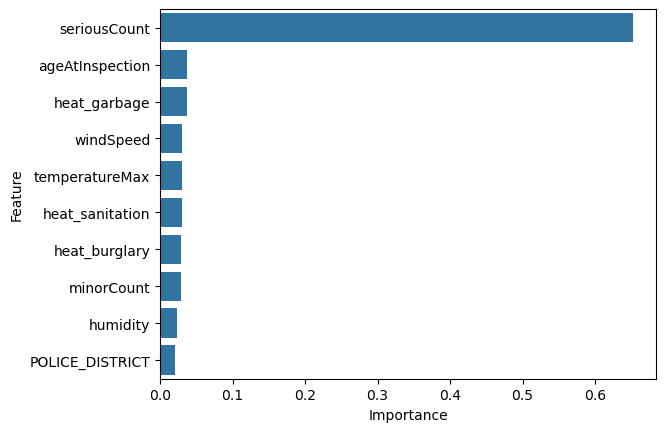

In [28]:
#fit the random forest model 
# fit the random forest on data to get feature importance
# ----------
rf_classifier.fit(X, y.ravel())

# import library
import seaborn as sns

# create feature importance dataframe
feat_importances = pd.concat([pd.DataFrame(X.columns),
                              pd.DataFrame(np.transpose(rf_classifier.feature_importances_))], axis = 1)
feat_importances.columns = ["Feature", "Importance"]

# plot 
sns.barplot(x = "Importance", 
            y = "Feature", 
            data = feat_importances.nlargest(10, 'Importance')) # identify the 10 most important features
plt.show()

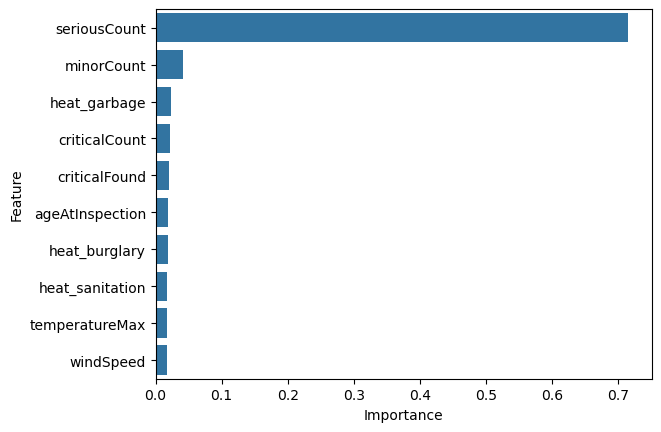

In [29]:
# fit the random forest on data to get feature importance
# ----------
rf_best.fit(X, y.ravel())

# import library
import seaborn as sns

# create feature importance dataframe
feat_importances = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(rf_best.feature_importances_))], axis = 1)
feat_importances.columns = ["Feature", "Importance"]

# plot 
sns.barplot(x = "Importance", 
            y = "Feature", 
            data = feat_importances.nlargest(10, 'Importance')) # identify the 10 most important features
plt.show()

###  Model 2 - Logistic Regression:

Logistic Regression: For my second model, I used logistic regression because it models statistical relationships in a straightforward and interpretable way.

Its major advantages include: (1) easier to interpret
                              (2) faster to run
                              (3) works well when relationships are linear

Its major disadvantages include: (1) harder to interpret for nonlinear relationships
                                 (2) can underperform when the data is complex

In [30]:
# Logistic Regression 
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

np.random.seed(10)

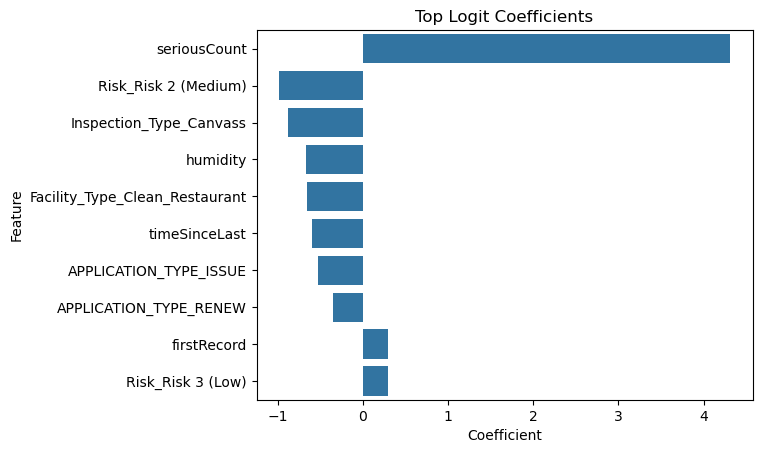

In [31]:
# training and test split 
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    train_size=0.80, 
                                                    test_size=0.20,
                                                    stratify=y)

# training and validation split 
X_train, X_validate, y_train, y_validate = train_test_split(X_train, 
                                                            y_train, 
                                                            train_size=0.75, 
                                                            test_size=0.25, 
                                                            stratify=y_train)

# create a model
logit_reg = LogisticRegression()

# fit the model
logit_model = logit_reg.fit(X_train, y_train.ravel())

# predict on the validation data
y_pred = logit_model.predict(X_validate)

# extract the coefficents and create a dataframe for plotting 
logit_data = pd.concat([pd.DataFrame(X.columns),
                        pd.DataFrame(np.transpose(logit_model.coef_))],
                       axis = 1)

logit_data.columns = ['Feature', 'Coefficient']
logit_data['abs_coef'] = abs(logit_data['Coefficient'])

# plot 
sns.barplot(x="Coefficient", 
            y="Feature", 
            data=logit_data.nlargest(10, 'abs_coef')).set_title("Top Logit Coefficients")
plt.show()

In [32]:
# hyperparameter tuning
# ----------
# import libraries
import warnings
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings(action='ignore')
from sklearn.metrics import accuracy_score

# set parameters
param_grid = {'penalty': ['l1', 'l2', 'elasticnet'],
             'C': np.arange(.1, 1, .1),
             'fit_intercept': [True, False],
             'solver': ['liblinear', 'saga']}

# execute the grid search and fit to training data
logit_grid = GridSearchCV(logit_model, 
                          param_grid, 
                          cv=3)
logit_grid.fit(X_train, 
               y_train)

# choose best performing model
best_index = np.argmax(logit_grid.cv_results_["mean_test_score"])
best_logit_pred = logit_grid.best_estimator_.predict(X_validate)

# print results
print(logit_grid.cv_results_["params"][best_index])
print('Validation Accuracy', accuracy_score(best_logit_pred, y_validate))

{'C': np.float64(0.1), 'fit_intercept': True, 'penalty': 'elasticnet', 'solver': 'liblinear'}
Validation Accuracy 0.9150881776616591


### Model 3 - XGBoost

3) XGBoost: Lastly, I used XGBoost. XGBoost is a powerful algorithm that builds an ensemble of decision trees sequentially, with each tree focusing on correcting the errors of the previous one. It is effective at capturing complex, non-linear relationships in the data.

Its main advantages are: (1) often achieves high accuracy
                         (2) can handle feature interactions effeciently
                         (3) built in regularlization that reduces overfitting
                         
Its main disadvantages are: (1) harder to explain because many trees can contribute to predictions
                            (2) requires tuning many hyperparameters

In [33]:
#xg boost 
import xgboost as xgb
from sklearn.metrics import make_scorer, accuracy_score, recall_score, precision_score, f1_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [34]:
# initialize an XGBoost classifier
# ----------
xgb_classifier = xgb.XGBClassifier(random_state=10)


# define the scoring metrics
scoring = {
          'accuracy': make_scorer(accuracy_score),
          'recall': make_scorer(recall_score),
          'precision': make_scorer(precision_score),
          'f1': make_scorer(f1_score)
          }


# perform cross-validation with 5-fold and return the trained estimators
cv_results = cross_validate(xgb_classifier,        # specify estimator 
                            X,                     # specify features
                            y.ravel(),             # specify outcome, and use ravel
                            cv=5,                  # specify 5-fold cross validation
                            return_estimator=True, # return the estimators fitted at each split
                            scoring=scoring)       # which scoring metrics to return (the whole list in this case)
 
# print the results for accuracy, recall, precision, and F1 score
for metric in ['test_accuracy', 'test_recall', 'test_precision', 'test_f1']:
    scores = cv_results[metric]
    print(f"{metric[5:]}: {scores.mean():.3f}")

accuracy: 0.919
recall: 0.839
precision: 0.779
f1: 0.807


In [35]:
#hyperparameter tuning for xgboost
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distributions to sample from
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 15),
    'learning_rate': uniform(0.01, 0.5),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5)
}

random_search_xgb = RandomizedSearchCV(
    xgb_classifier,
    param_distributions=param_dist,
    n_iter=50,               # number of combinations to try
    scoring='accuracy',      # or 'f1', 'roc_auc', etc.
    cv=5,
    n_jobs=-1,               # use all cores
    verbose=2,
    random_state=10
)

random_search_xgb.fit(X, y)
print("Best parameters:", random_search_xgb.best_params_)
print("Best CV score:", random_search_xgb.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'colsample_bytree': np.float64(0.8856603216333729), 'learning_rate': np.float64(0.020375974679700752), 'max_depth': 3, 'n_estimators': 469, 'subsample': np.float64(0.8744019412693059)}
Best CV score: 0.924956044980086


In [36]:
#best parameters from hyperparameter tuning xgboost 

xgb_best = xgb.XGBClassifier(
    colsample_bytree=float(0.8869151481052979),
    subsample=float(0.6574634359213442),
    learning_rate=float(0.029979604344988635),
    max_depth=4,
    n_estimators=278,
    random_state=10,
)  

scoring_best = {
          'accuracy': make_scorer(accuracy_score),
          'recall': make_scorer(recall_score),
          'precision': make_scorer(precision_score),
          'f1': make_scorer(f1_score)
          }


# perform cross-validation with 5-fold and return the trained estimators
cv_results = cross_validate(xgb_best,        # specify estimator 
                            X,                     # specify features
                            y.ravel(),             # specify outcome, and use ravel
                            cv=5,                  # specify 5-fold cross validation
                            return_estimator=True, # return the estimators fitted at each split
                            scoring=scoring)       # which scoring metrics to return (the whole list in this case)
 
# print the results for accuracy, recall, precision, and F1 score
for metric in ['test_accuracy', 'test_recall', 'test_precision', 'test_f1']:
    scores_best = cv_results[metric]
    print(f"{metric[5:]}: {scores_best.mean():.3f}")

accuracy: 0.925
recall: 0.893
precision: 0.772
f1: 0.827


### Validation Metrics

Be sure to explain which of these metrics you would want to prioritize when conducting predictive auditing in this context and why.

**Hint**: Try writing a for loop to use [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) to check for accuracy, precision, recall and f1 across all of your models.

I would priortize accuracy, precision, recall, and F1 for food inspection. My main priority is public safety since we're dealing with food inspection (a wrong mistake can result in food sickness which is far from ideal). 

When comparing the models using accuracy, precision, recall, and F1 for food inspection, I believe the most important metric for predictive auditing is recall and F1 score. 

Recall can measure how good the model is at finding every single restaurant that is unsafe. The reason why this is important is because missing a dirty restaurant is more dangerous than being extra safe and checking a few extra clean places. 

The F1 score is also useful because it makes sure the model is still accurate while dealing with imbalanced data. 

In [37]:
rf_best = RandomForestClassifier(
    bootstrap=True,
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=7,
    min_samples_split=11,
    n_estimators=140,
    random_state=10
)

logit_best = LogisticRegression(
    penalty='l2',
    C=0.3,
    fit_intercept=True,
    solver='liblinear',
    max_iter=5000,
    random_state=10
)

xgb_best = xgb.XGBClassifier(
    colsample_bytree=float(0.8869151481052979),
    subsample=float(0.6574634359213442),
    learning_rate=float(0.029979604344988635),
    max_depth=4,
    n_estimators=278,
    random_state=10,
)  

#for loop to compare models using cross_val_score to check for accuracy, precision, recall, and f1 across the three models
from sklearn.model_selection import cross_val_score
models = {
    'Random Forest': rf_best,
    'Logistic Regression': logit_best,
    'XGBoost': xgb_best
}
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']
for model_name, model in models.items():
    print(f"Results for {model_name}:")
    for metric in scoring_metrics:
        scores = cross_val_score(model, X, y.ravel(), cv=5, scoring=metric)
        print(f"  {metric.capitalize()}: {scores.mean():.3f}")
    print()    

Results for Random Forest:
  Accuracy: 0.925
  Precision: 0.765
  Recall: 0.912
  F1: 0.831

Results for Logistic Regression:
  Accuracy: 0.922
  Precision: 0.786
  Recall: 0.845
  F1: 0.813

Results for XGBoost:
  Accuracy: 0.925
  Precision: 0.772
  Recall: 0.893
  F1: 0.827




Here we see that all three models perform well, but Random Forest and XGBoost have the highest accuracy at 92.5%.
Random Forest has the strongest recall at 0.912, making it the best at identifying true failing establishments, which is helpful in predictive auditing. Logistic regression offers the highest precision (0.786), making it slightly better at reducing false alarms. And finally, RF has the highest value for F1 (0.831) with XGBoost being a close second (0.827)


## 4. Policy Simulation

### Interpretable Machine Learning

Use tools like coefficient plots or feature importance plots to investigate your models. Which features contribute to your predictions? Are there any additional features you wish you could incorporate that you don't have available in this analysis?

**Hint**: Use tools like feature importance plots and coefficient plots.

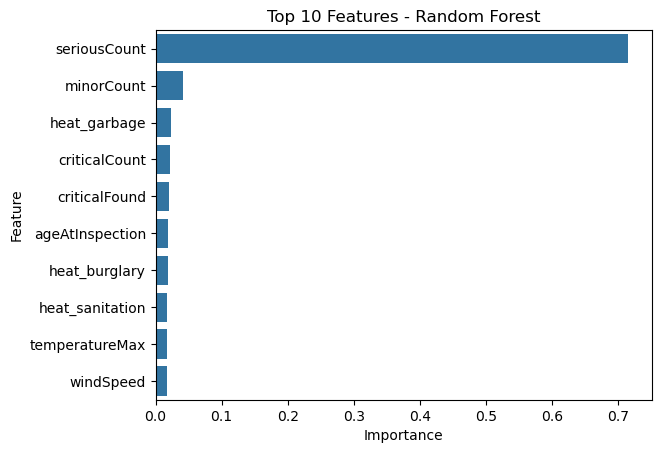

In [38]:
#feature importance for random forest with best parameters
rf_best.fit(X, y.ravel())

# import library
import seaborn as sns

# create feature importance dataframe
feat_importances = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(rf_best.feature_importances_))], axis = 1)
feat_importances.columns = ["Feature", "Importance"]

# plot 
sns.barplot(x = "Importance", 
            y = "Feature", 
            data = feat_importances.nlargest(10, 'Importance')) # identify the 10 most important features
plt.title("Top 10 Features - Random Forest")
plt.show()

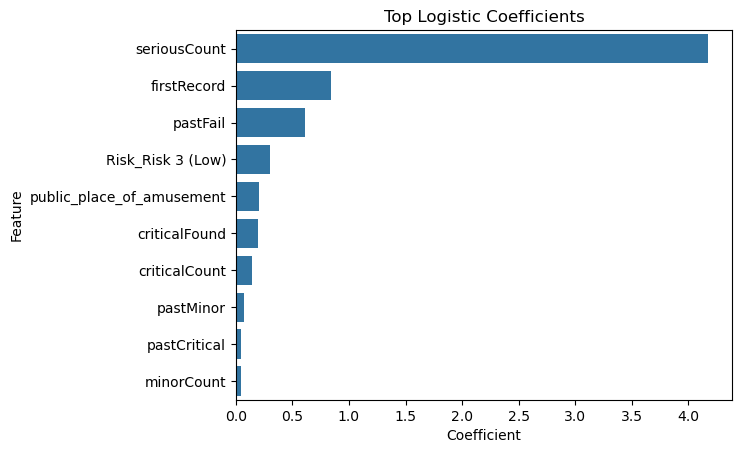

In [68]:
# Fit logistic regression with best parameters
logit_best.fit(X, y.ravel())

# import seaborn
import seaborn as sns

# create a dataframe for coefficients
logit_coefficient = pd.concat([
    pd.DataFrame(X.columns),
    pd.DataFrame(np.transpose(logit_best.coef_))
], axis=1)

logit_coefficient.columns = ["Feature", "Coefficient"]

# compute absolute value to determine importance
logit_coefficient["Importance"] = logit_coefficient["Coefficient"].abs()

# plot top 10 features by absolute coefficient
sns.barplot(
    x="Coefficient",
    y="Feature",
    data=logit_coefficient.nlargest(10, "Coefficient")
)
plt.title("Top Logistic Coefficients")
plt.show()

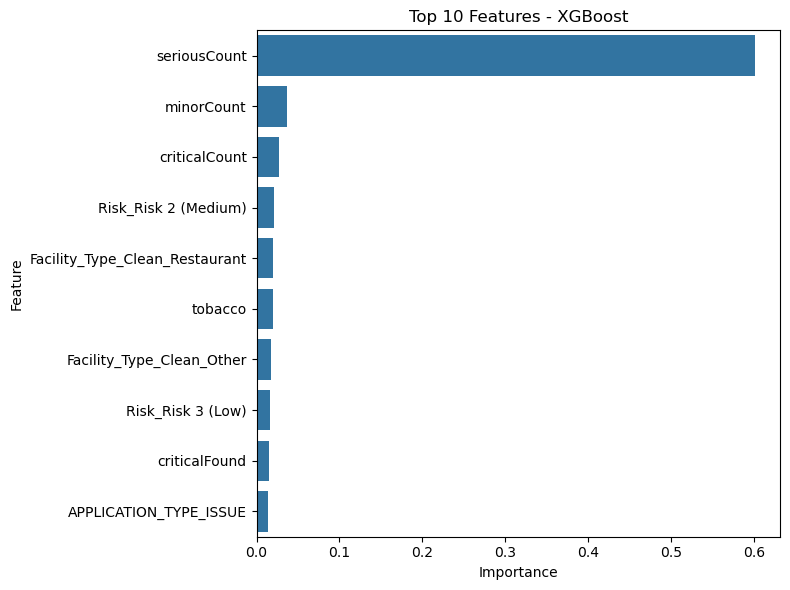

In [40]:
#xg boost feature importance with best parameters
xgb_best.fit(X, y.ravel())

feat_importances_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_best.feature_importances_
})

# 3. Keep the top 10 most important features
top10_xgb = feat_importances_xgb.sort_values(
    by="Importance",
    ascending=False
).head(10)

# 4. Plot
plt.figure(figsize=(8, 6))
sns.barplot(
    data=top10_xgb,
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Features - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


WORK ON THIS

Across all three models, the most prominent feature is the indicator of a recent violation, specifically seriousCount. With XGBoost and Random Forest, seriousCount is very important, while for logistic regression it is a high value coeffecient. For XGBoost and RF, minorCount is the next most important variable, while for logistic regression the next highest coeffecient is the firstRecord variable. All 3 analyses included varying levels of importance/value to criticalCount, and Risk levels (2 and 3 in particular). These patterns suggest that a dining establishments past and it's risk classification play a large role in predicting if the establishment will fail in the future. It was interesting observing how differently the 3 models determined which variables were essential/

It would be helpful to include variables like restaurant size and if the restaurant is a franchise or a small mom and pop diner. It would also be helpful to include variables on when was the last time the restaurant provided training for staff on sanitary procedures. 

### Prioritize Audits

**Hint**: Look up the [`.predict()`](https://www.kite.com/python/docs/sklearn.linear_model.SGDRegressor.predict), [`.predict_proba()`](https://www.kite.com/python/docs/sklearn.linear_model.LogisticRegression.predict_proba), and [`.sample()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html) methods. Then: 
1. Choose one of your models (or train a new simplified model or ensemble!) to predict outcomes and probabilities. 
2. Order your audits by their probability of detecting a "Fail" score
3. Plot your distribution of pass/fail among the first 1,000 observations in the dataset
4. Simulate random audits on the full chicago_2011_to_2013.csv dataset by picking 1,000 observations at random

In [41]:
#
# 1. Choose one of your models (or train a new simplified model or ensemble!) to predict outcomes and probabilities.
# -----------

xgb_best = xgb.XGBClassifier(
    colsample_bytree=float(0.8869151481052979),
    subsample=float(0.6574634359213442),
    learning_rate=float(0.029979604344988635),
    max_depth=4,
    n_estimators=278,
    random_state=10,
)

xgb_best.fit(X, y.ravel())

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8869151481052979, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.029979604344988635,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=278, n_jobs=None,
              num_parallel_tree=None, ...)

In [42]:
#
# 2. Order your audits by their probability of detecting a "Fail" score
# -----------
# Find which column in predict_proba corresponds to the "Fail" class = 1
fail_class_index = list(xgb_best.classes_).index(1)  

# Predicted probabilities for Fail
prob_fail = xgb_best.predict_proba(X)[:, fail_class_index]

# DataFrame linking each row to prob_fail and true label
audit_scores = pd.DataFrame({
    "prob_fail": prob_fail,
    "true_label": y.ravel()
}, index=X.index)

# Order by highest probability of Fail
audit_scores_sorted = audit_scores.sort_values("prob_fail", ascending=False)

Top 1,000 (targeted) audits — counts:
true_label
1    982
0     18
Name: count, dtype: int64

Top 1,000 (targeted) audits — shares:
true_label
1    0.982
0    0.018
Name: proportion, dtype: float64


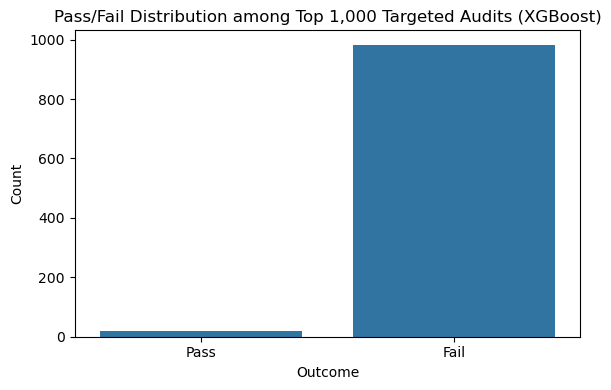

In [43]:
#
# 3. Plot your distribution of pass/fail among the first 1,000 observations in the dataset
# -----------
# Take first 1,000 rows after sorting (most risky)
top_1000 = audit_scores_sorted.head(1000)

print("Top 1,000 (targeted) audits — counts:")
print(top_1000["true_label"].value_counts())
print("\nTop 1,000 (targeted) audits — shares:")
print(top_1000["true_label"].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(x="true_label", data=top_1000)
plt.xticks([0, 1], ["Pass", "Fail"])
plt.title("Pass/Fail Distribution among Top 1,000 Targeted Audits (XGBoost)")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

This figure helps us determine that our XGBoost model is useful since it effectively determined that most of the top 1000 riskiest businesses failed inspections. This makes sense since I ordered, the data to list our the top 1000 businesses that are most likely to fail. The XGboost model is effective at identifying high risk establishments, and is useful for priortized auditing. 

Random 1,000 audits — counts:
true_label
0    797
1    203
Name: count, dtype: int64

Random 1,000 audits — shares:
true_label
0    0.797
1    0.203
Name: proportion, dtype: float64


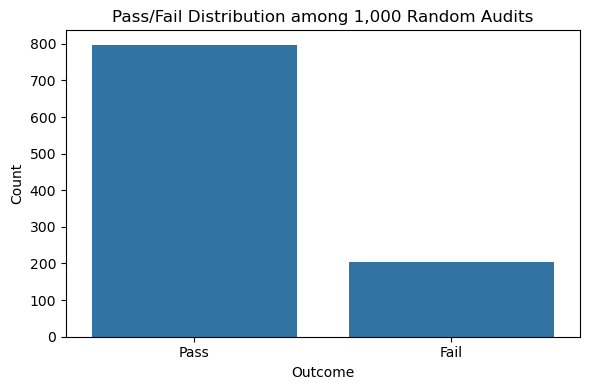

In [44]:
#
# 4. Simulate random audits on the full chicago_2011_to_2013.csv dataset by picking 1,000 observations at random
# -----------
# Randomly sample 1,000 observations from the full dataset
random_1000 = audit_scores.sample(n=1000, random_state=42)

print("Random 1,000 audits — counts:")
print(random_1000["true_label"].value_counts())
print("\nRandom 1,000 audits — shares:")
print(random_1000["true_label"].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(x="true_label", data=random_1000)
plt.xticks([0, 1], ["Pass", "Fail"])
plt.title("Pass/Fail Distribution among 1,000 Random Audits")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

After conducting 1,000 random audits, my model passed about approximately 80% of the businesses. However, random inspections may not be ideal since random inspections are expensive. It would be better to focus on high risk businesses to improve overall health metrics.

### Predict on 2014 inspection data

Use your favorite model to make predictions based on the features using the "Chicago Inspection 2014_updated.csv" file. Treat this as you would a test dataset. This means you will have to format the features (including removing some features and getting dummies) and the label (binarize and recode) in the same way you did the training data. (Remember the "Results" column is your label). You will then compare your predictions with the actual.

In [63]:
chicago_inspections_2014.head()

,Inspection_ID,Inspection_Date,DBA_Name,AKA_Name,License,Facility_Type,Risk,Address,City,State,Zip,Inspection_Type,Latitude,Longitude,Location,Facility_Type_Clean,criticalCount,seriousCount,minorCount,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,ID,LICENSE_ID,ACCOUNT_NUMBER,LEGAL_NAME,DOING_BUSINESS_AS_NAME,ADDRESS,CITY,STATE,ZIP_CODE,WARD,PRECINCT,WARD_PRECINCT,POLICE_DISTRICT,LICENSE_CODE,LICENSE_DESCRIPTION,BUSINESS_ACTIVITY_ID,BUSINESS_ACTIVITY,LICENSE_NUMBER,APPLICATION_TYPE,LICENSE_TERM_START_DATE,LICENSE_TERM_EXPIRATION_DATE,LICENSE_STATUS,LATITUDE,LONGITUDE,minDate,maxDate,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound,Results
0,920444,2014-01-15,GALLISTEL LANGUAGE ACADEMY,GALLISTEL LANGUAGE ACADEMY,2046708,School,Risk 1 (High),10200 S AVENUE J,CHICAGO,IL,60617.0,Canvass,41.709957,-87.534223,"(41.70995714781606, -87.5342225149751)",Other,0,1,5,0,0,0,2,0.964384,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,41.67,13.533333,0.726667,2.149376,7.705332,9.535848,0,Fail
1,920445,2014-02-03,SUBWAY,SUBWAY,2183563,Restaurant,Risk 1 (High),4025 E 106TH ST,CHICAGO,IL,60617.0,Canvass,41.702577,-87.525872,"(41.70257660937248, -87.52587169711877)",Restaurant,2,0,0,0,0,0,0,0.794521,0,2183563-20120829,2183563.0,375027.0,AMI SUB INC.,SUBWAY,4025 E 106TH ST 1,CHICAGO,IL,60617.0,10.0,38.0,10-38,4.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,2183563.0,ISSUE,2012-08-29,2014-09-15,AAI,41.702577,-87.525872,2012-08-29,2018-09-15,1.432877,0,0,0,0,0,0,0,0,0,0,0,0,0.002300,28.16,6.020000,0.746667,12.034833,7.194320,1.219222,1,Pass w/ Conditions
2,920446,2014-02-03,SHARKS FISH & CHICKEN,SHARKS FISH & CHICKEN,1477112,Restaurant,Risk 2 (Medium),2027 E 95TH ST,CHICAGO,IL,60617.0,Canvass,41.722372,-87.574275,"(41.72237211196818, -87.57427469548966)",Restaurant,0,0,6,0,0,0,2,0.660274,0,1477112-20120716,2155150.0,273266.0,"A & K SHARKS, INC.",SHARKS FISH & CHICKEN,2027 E 95TH ST,CHICAGO,IL,60617.0,7.0,49.0,7-49,4.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1477112.0,RENEW,2012-07-16,2014-07-15,AAI,41.722372,-87.574275,2004-03-02,2018-07-15,9.931507,0,0,0,0,0,0,0,0,0,0,0,0,0.002300,28.16,6.020000,0.746667,26.292725,27.837325,12.401466,0,Pass
3,920448,2014-03-07,P K PETRO INC.,MARATHON,1331469,Grocery Store,Risk 3 (Low),7001 S STONY ISLAND AVE,CHICAGO,IL,60649.0,Canvass,41.767798,-87.585820,"(41.76779762303839, -87.58581991823232)",Other,0,1,7,0,0,0,0,2.000000,1,1331469-20121216,2194284.0,257899.0,P K PETRO INC.,Stony Shell,7001 S STONY ISLAND AVE,CHICAGO,IL,60649.0,5.0,21.0,5-21,3.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1331469.0,RENEW,2012-12-16,2014-12-15,AAI,41.767798,-87.585820,2003-03-05,2018-12-15,11.013699,0,1,0,0,0,0,0,0,0,1,0,0,0.000433,25.30,7.653333,0.636667,49.468944,11.282325,66.467028,0,Fail
4,920449,2014-03-07,"Z T DOLLAR EXCHANGE,INC",DOLLAR STORE,2189299,Grocery Store,Risk 3 (Low),2429 E 72ND ST,CHICAGO,IL,60649.0,Canvass,41.764339,-87.565371,"(41.764339216775696, -87.5653706801239)",Other,1,2,5,0,0,0,0,2.000000,1,2189299-20121009,2189299.0,249904.0,"ZT DOLLAR EXCHANGE, INC.","Z T DOLLAR EXCHANGE, INC.",2429 E 72ND ST,CHICAGO,IL,60649.0,7.0,40.0,7-40,3.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,2189299.0,ISSUE,2012-10-09,2014-12-15,AAI,41.764339,-87.565371,2012-10-09,2018-12-15,1.408219,0,1,0,0,0,1,0,0,0,0,0,0,0.000433,25.30,7.653333,0.636667,69.939833,26.695701,76.827119,1,Fail


In [64]:
chicago_inspections_2014.columns

Index(['Inspection_ID', 'Inspection_Date', 'DBA_Name', 'AKA_Name', 'License',
       'Facility_Type', 'Risk', 'Address', 'City', 'State', 'Zip',
       'Inspection_Type', 'Latitude', 'Longitude', 'Location',
       'Facility_Type_Clean', 'criticalCount', 'seriousCount', 'minorCount',
       'pastFail', 'pastCritical', 'pastSerious', 'pastMinor', 'timeSinceLast',
       'firstRecord', 'ID', 'LICENSE_ID', 'ACCOUNT_NUMBER', 'LEGAL_NAME',
       'DOING_BUSINESS_AS_NAME', 'ADDRESS', 'CITY', 'STATE', 'ZIP_CODE',
       'WARD', 'PRECINCT', 'WARD_PRECINCT', 'POLICE_DISTRICT', 'LICENSE_CODE',
       'LICENSE_DESCRIPTION', 'BUSINESS_ACTIVITY_ID', 'BUSINESS_ACTIVITY',
       'LICENSE_NUMBER', 'APPLICATION_TYPE', 'LICENSE_TERM_START_DATE',
       'LICENSE_TERM_EXPIRATION_DATE', 'LICENSE_STATUS', 'LATITUDE',
       'LONGITUDE', 'minDate', 'maxDate', 'ageAtInspection',
       'consumption_on_premises_incidental_activity', 'tobacco',
       'package_goods', 'outdoor_patio', 'public_place_of_amusement

In [65]:
# data processing
# -----------
chicago_inspections_2014.drop(columns = ['AKA_Name', 
                                                 'License',
                                                 'Address',
                                                 'City',
                                                 'State',
                                                 'Zip',
                                                 'Latitude',
                                                 'Longitude',
                                                 'Location',
                                                 'ID',
                                                 'LICENSE_ID',
                                                 'LICENSE_TERM_START_DATE',
                                                 'LICENSE_TERM_EXPIRATION_DATE',
                                                 'LICENSE_STATUS',
                                                 'ACCOUNT_NUMBER',
                                                 'LEGAL_NAME',
                                                 'DOING_BUSINESS_AS_NAME',
                                                 'ADDRESS',
                                                 'CITY',
                                                 'STATE',
                                                 'ZIP_CODE',
                                                 'WARD',
                                                 'PRECINCT',
                                                 'LICENSE_CODE',
                                                 'BUSINESS_ACTIVITY_ID',
                                                 'BUSINESS_ACTIVITY',
                                                 'LICENSE_NUMBER',
                                                 'LATITUDE',
                                                 'LONGITUDE'],
                                     inplace = True, errors='ignore')

#set index 
chicago_inspections_2014.set_index(['Inspection_ID', 'DBA_Name'], inplace = True)

#convert the inspection date to a datetime format
chicago_inspections_2014['Inspection_Date'] = pd.to_datetime(chicago_inspections_2014['Inspection_Date'])

#drop datetime info
chicago_inspections_2014 = chicago_inspections_2014.dropna().drop(['Inspection_Date',
                                                                                   'minDate',
                                                                                   'maxDate'],
                                                                                  axis = 1)

#drop rows with missing data 
chicago_inspections_2014 = chicago_inspections_2014.dropna()

# process features
X_test2014 = chicago_inspections_2014.drop(columns = ['Results',
                                                        'Facility_Type', 
                                                     'LICENSE_DESCRIPTION', 
                                                     'WARD_PRECINCT'])

# process target 
y_test2014 = chicago_inspections_2014['Results']

#get dummies
X_test2014 = pd.get_dummies(X_test2014)

In [66]:
# predict and compare 
# -----------
y_pred = xgb_best.predict(X_test2014)

y_proba_2014 = xgb_best.predict_proba(X_test2014)

Accuracy: 0.906
Precision: 0.725
Recall: 0.849
F1 Score: 0.782


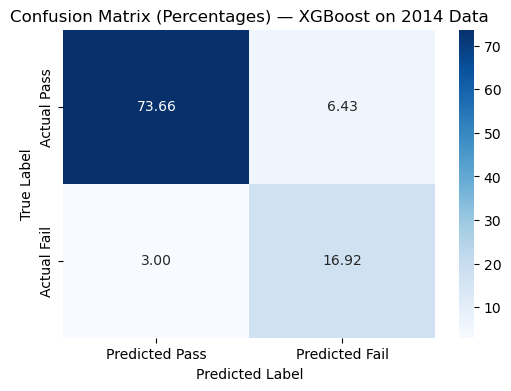

In [67]:
# evaluate
# -----------

accuracy = accuracy_score(y_test2014.replace({'Pass w/ Conditions': 'Pass'}).replace({'Pass': 0, 'Fail': 1}), y_pred)
precision = precision_score(y_test2014.replace({'Pass w/ Conditions': 'Pass'}).
replace({'Pass': 0, 'Fail': 1}), y_pred)
recall = recall_score(y_test2014.replace({'Pass w/ Conditions': 'Pass'}).replace({'Pass': 0, 'Fail': 1}), y_pred)
f1 = f1_score(y_test2014.replace({'Pass w/ Conditions': 'Pass'}).replace({'Pass': 0, 'Fail': 1}), y_pred)

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")


#compare results with actual results from 2014 data with a confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# Convert labels
y_true = y_test2014.replace({'Pass w/ Conditions': 'Pass'}).replace({'Pass': 0, 'Fail': 1})

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Convert to percentages
cm_percent = cm / cm.sum() * 100

plt.figure(figsize=(6, 4))
sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Predicted Pass', 'Predicted Fail'],
            yticklabels=['Actual Pass', 'Actual Fail'])

plt.title('Confusion Matrix (Percentages) — XGBoost on 2014 Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The confusion matrix demonstrates that the XGBoost Model is good at prediction inspection outcomes for 2014. The confusion matrix states that the model predicts 73% of all passes while predicting 17% of all fails. It also illustrates a low false-negative and false-positive rate which means that the model rarely misses a busines sthat truly fails health metrics. All in all, the model is effective at distinguishing between compliant and non-compliant restaurants.

## 5. Discussion Questions

1. Why do we need metrics beyond accuracy when using machine learning in the social sciences and public policy?


In social sciences and policy, metrics beyond accuracy are extremely important since not all errors are equal. If we only focus on accuracy, then all mistakes would be treated equally without accounting for how different errors can significantly impact outcomes. For example if the model misses a really bad restaurant (i.e., multiple violations of health standards) then that can be extremely harmful. It is more harmful in this case to have a false negative than to incorrectly flag a false positive. 

That is why we need metrics like precision and/or recall to understand what kind of mistakes the model is making along with their magnitude to adequately address impact.

2. Imagine that establishments learned about the algorithm being used to determine who gets audited and they started adjusting their behavior (and changing certain key features about themselves that were important for the prediction) to avoid detection. How could policymakers address this interplay between algorithmic decisionmaking and real world behavior?

For policymakers, it would be important to regularly update the models in the event that restaurants adjust their behavior. Failure to update the model to changing circumstances can result in an outdated model that fails to accurately capture health metrics. Policymakers can incorporate a mixture of short term and long term indicators that are harder to manipulate (e.g., neighborhood socioeconomic conditions, historic data on customer complaints, etc.)

And finally, including randomness in the audits (e.g., random inspections throughout a time period) can prevent businessess from trying to adhere to health regulations simply before an inspection. 